In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
byol = pd.read_csv("runs/byol/metrics.csv")
simsiam = pd.read_csv("runs/simsiam/metrics.csv")
simsiam_nosg = pd.read_csv("runs/simsiam_nosg/metrics.csv")
simsiam_nopred = pd.read_csv("runs/simsiam_nopred/metrics.csv")

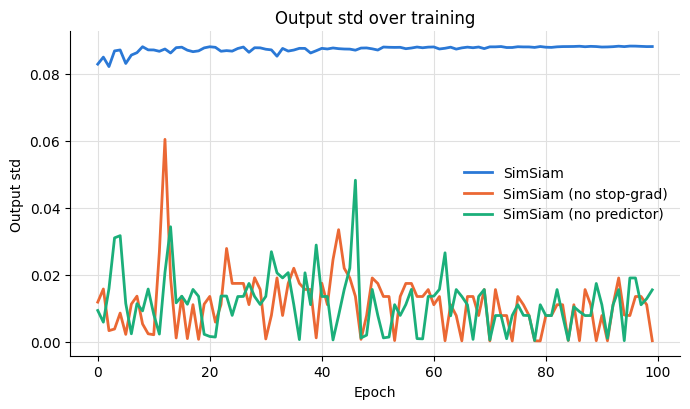

In [25]:
runs = {
    "SimSiam": simsiam,
    "SimSiam (no stop-grad)": simsiam_nosg,
    "SimSiam (no predictor)": simsiam_nopred,
}
colors = ["#2a78d6", "#eb6834", "#1baf7a"]

fig, ax = plt.subplots(figsize=(7, 4.2))
for (label, df), color in zip(runs.items(), colors):
    ax.plot(df["epoch"], df["output_std"], label=label, color=color, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Output std")
ax.set_title("Output std over training")
ax.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

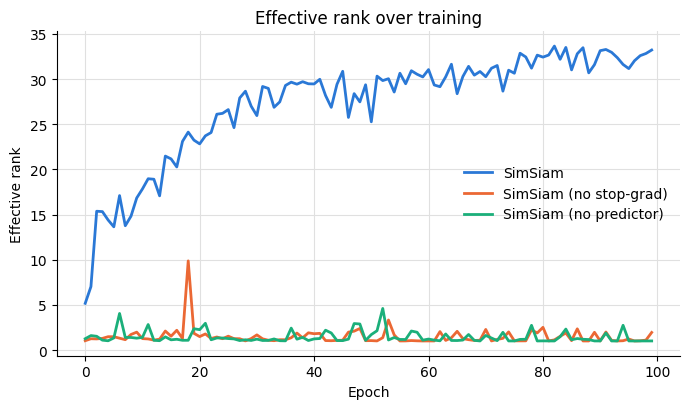

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for (label, df), color in zip(runs.items(), colors):
    ax.plot(df["epoch"], df["effective_rank"], label=label, color=color, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Effective rank")
ax.set_title("Effective rank over training")
ax.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\aarus\AppData\Local\Temp\ipykernel_28516\674419823.py:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.plot(sv, label=f"{label} (eff. rank = {er:.1f}, $\sigma_1$ = {sv[0]:.1f})", color=color, linewidth=2)
c:\Users\aarus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


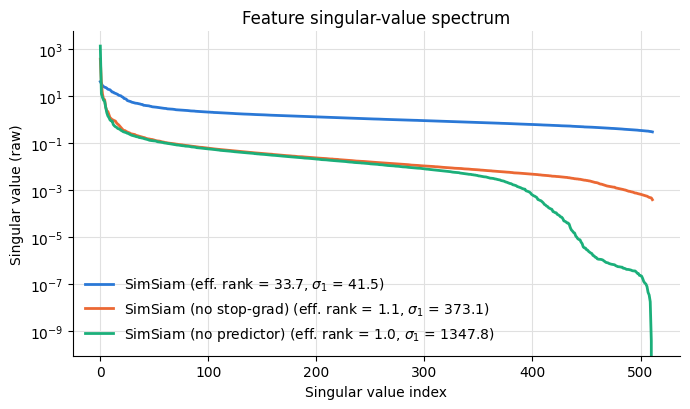

In [27]:
# Raw (un-normalized) singular-value spectra, recomputed from each run's encoder.pt.
# Mirrors diagnostics.py: one batch of 1024 SSL views -> encoder -> center -> svdvals,
# but skips the "sv / sv.max()" step so absolute feature scale is kept on the y-axis.
import os
import torch
from torch.utils.data import DataLoader
import data, metrics
from models import cifar_encoder

spectrum_runs = {
    "SimSiam": "runs/simsiam",
    "SimSiam (no stop-grad)": "runs/simsiam_nosg",
    "SimSiam (no predictor)": "runs/simsiam_nopred",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
ds = data.get_ssl_dataset("./data", train=True)

def raw_singular_values(ckpt_path, batch=1024, seed=0):
    enc, _ = cifar_encoder()
    enc.load_state_dict(torch.load(ckpt_path, map_location=device)["encoder"])
    enc.to(device).eval()
    torch.manual_seed(seed)  # same images + augmentations for every run
    loader = DataLoader(ds, batch_size=batch, shuffle=True, num_workers=0, drop_last=True)
    (x1, _), _ = next(iter(loader))
    with torch.no_grad():
        f1 = enc(x1.to(device))
    er, sv = metrics.effective_rank(f1)
    return er, sv.numpy()

fig, ax = plt.subplots(figsize=(7, 4.2))
for (label, run_dir), color in zip(spectrum_runs.items(), colors):
    ckpt = os.path.join(run_dir, "encoder.pt")
    if not os.path.exists(ckpt):
        print(f"skipping {label}: {ckpt} not found")
        continue
    er, sv = raw_singular_values(ckpt)
    ax.plot(sv, label=f"{label} (eff. rank = {er:.1f}, $\sigma_1$ = {sv[0]:.1f})", color=color, linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value (raw)")
ax.set_title("Feature singular-value spectrum")
ax.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [28]:
simclr = pd.read_csv("runs/simclr/metrics.csv")
simclr_T02 = pd.read_csv("runs/simclr_T0.2/metrics.csv")
simclr_T01 = pd.read_csv("runs/simclr_T0.1/metrics.csv")
simclr_T10 = pd.read_csv("runs/simclr_T1.0/metrics.csv")

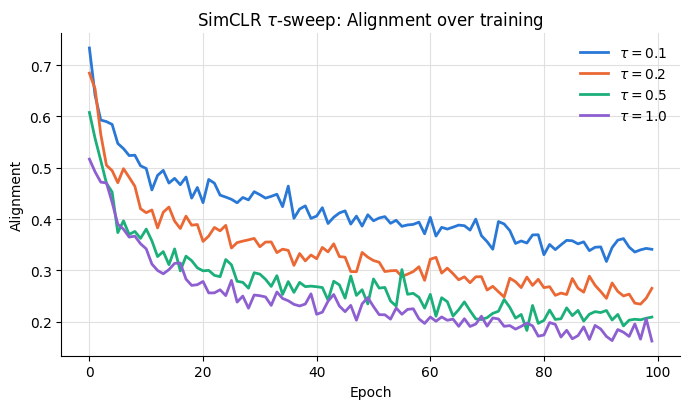

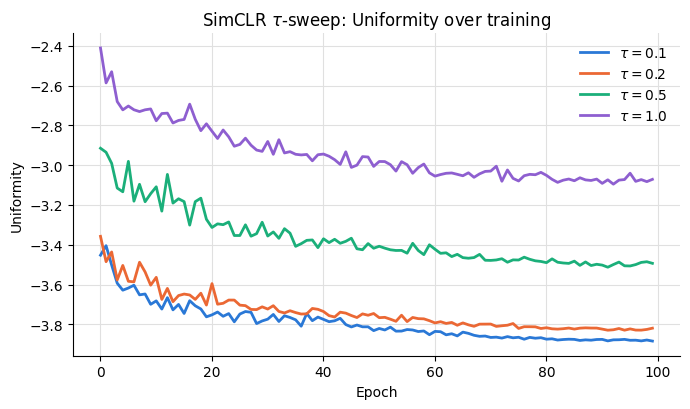

In [29]:
# SimCLR temperature sweep: alignment / uniformity per epoch, linear-probe accuracy at the end.
# runs/simclr is the default-temperature run (tau = 0.5).
simclr_T0_1 = pd.read_csv("runs/simclr_T0.1/metrics.csv")
simclr_T0_2 = pd.read_csv("runs/simclr_T0.2/metrics.csv")
simclr_T0_5 = simclr
simclr_T1_0 = pd.read_csv("runs/simclr_T1.0/metrics.csv")

temp_runs = {
    0.1: (simclr_T0_1, "runs/simclr_T0.1"),
    0.2: (simclr_T0_2, "runs/simclr_T0.2"),
    0.5: (simclr_T0_5, "runs/simclr"),
    1.0: (simclr_T1_0, "runs/simclr_T1.0"),
}
temp_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5fd0"]

def probe_accuracy(run_dir):
    with open(os.path.join(run_dir, "linear probe test accuracy.txt")) as f:
        return float(f.read().strip().rstrip("%"))

def style(ax, ylabel, title):
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, color="#e0e0e0", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)

for metric, ylabel in [("alignment", "Alignment"), ("uniformity", "Uniformity")]:
    fig, ax = plt.subplots(figsize=(7, 4.2))
    for (tau, (df, _)), color in zip(temp_runs.items(), temp_colors):
        ax.plot(df["epoch"], df[metric], label=rf"$\tau = {tau}$", color=color, linewidth=2)
    style(ax, ylabel, r"SimCLR $\tau$-sweep: " + f"{ylabel} over training")
    plt.tight_layout()
    plt.show()

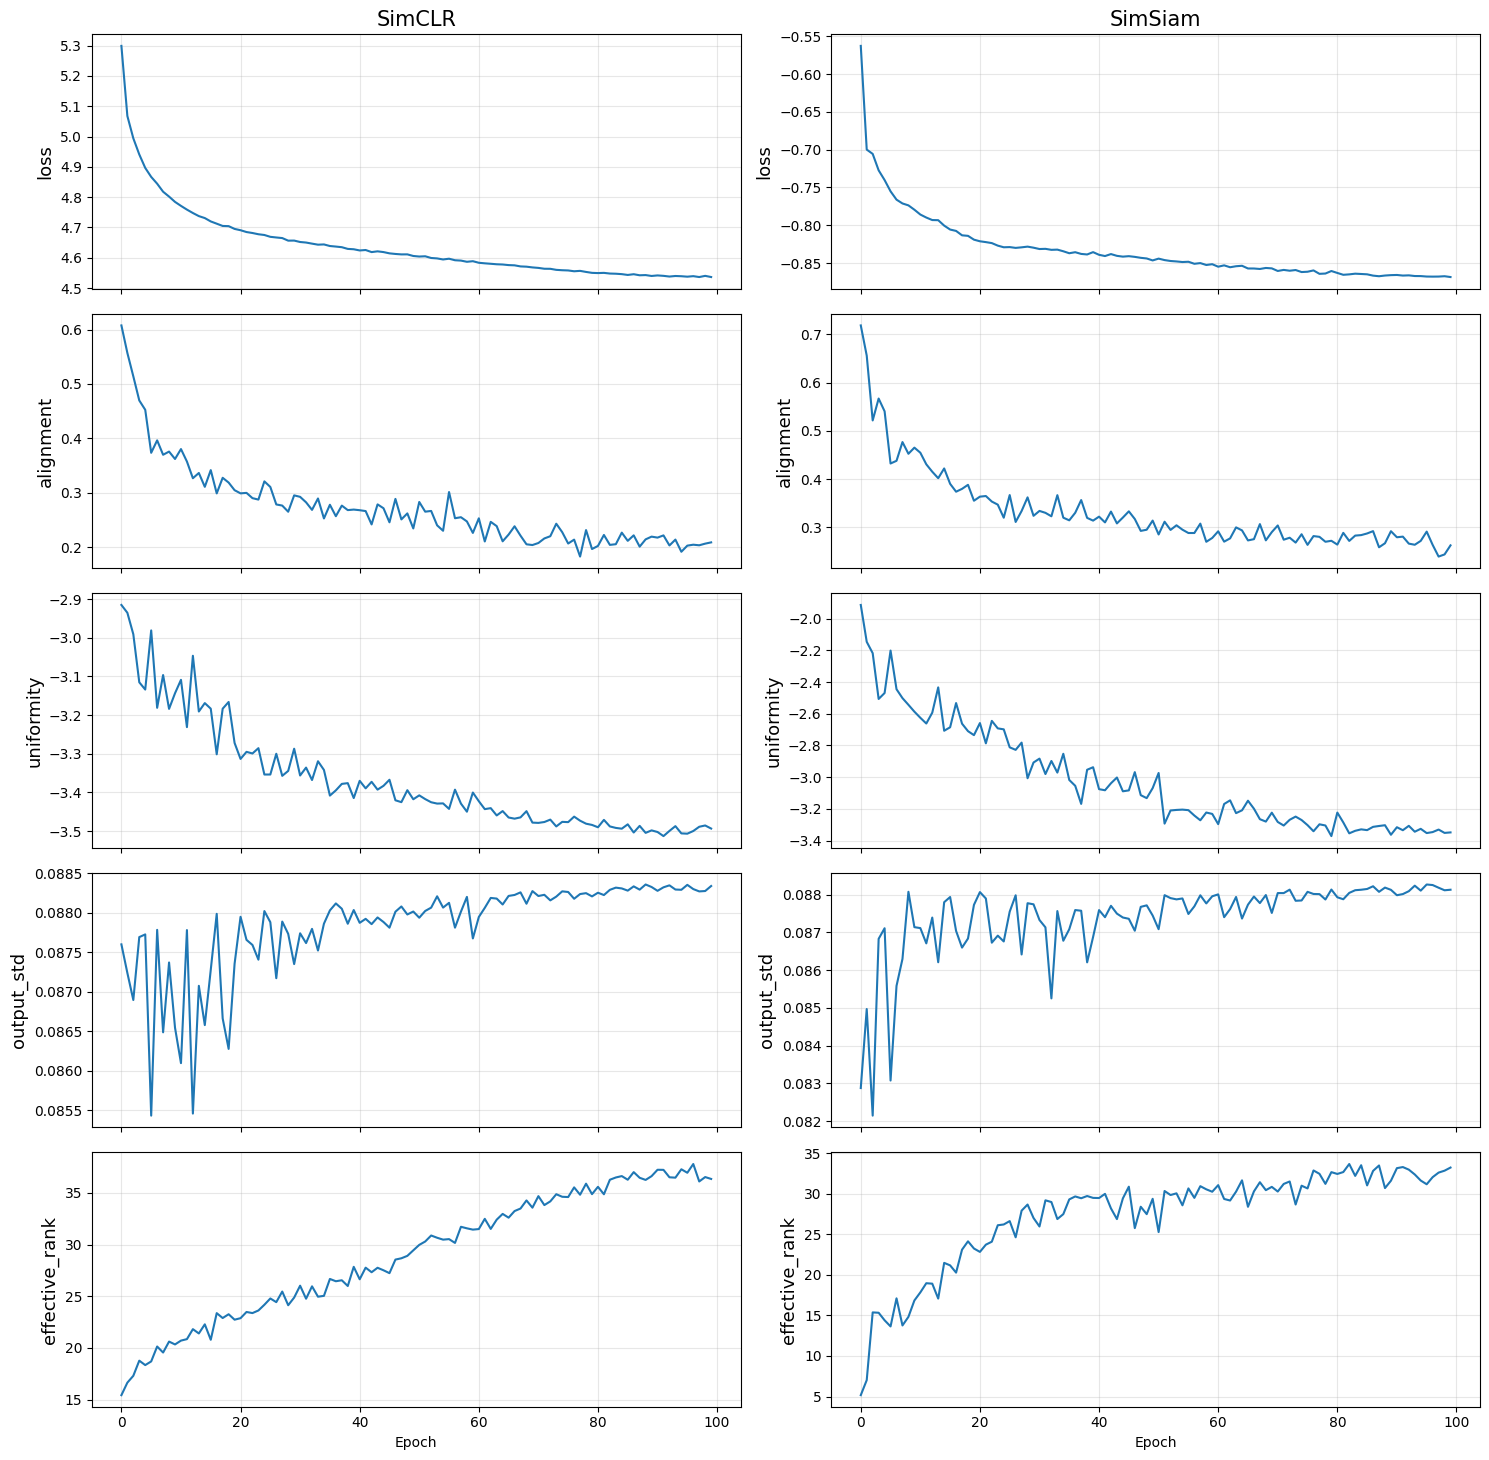

In [30]:
metrics = [
    "loss",
    "alignment",
    "uniformity",
    "output_std",
    "effective_rank"
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 15),
    sharex=True
)

for i, metric in enumerate(metrics):

    # SimCLR
    axes[i, 0].plot(simclr["epoch"], simclr[metric])
    axes[i, 0].set_ylabel(metric,fontsize=13)
    axes[i, 0].grid(alpha=0.3)

    # SimSiam
    axes[i, 1].plot(simsiam["epoch"], simsiam[metric])
    axes[i, 1].set_ylabel(metric,fontsize=13)
    axes[i, 1].grid(alpha=0.3)

    # Column titles
    if i == 0:
        axes[i, 0].set_title("SimCLR", fontsize=15)
        axes[i, 1].set_title("SimSiam", fontsize=15)

# x-axis label only on bottom row
axes[-1, 0].set_xlabel("Epoch")
axes[-1, 1].set_xlabel("Epoch")


plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [36]:
simclr_b128 = pd.read_csv("runs/simclr_b128/metrics.csv")
simclr_b512 = pd.read_csv("runs/simclr_b512/metrics.csv")
print(simclr_b128.iloc[99])
print(simclr_b512.iloc[99])

epoch             99.000000
loss               3.804878
alignment          0.162420
uniformity        -3.524029
output_std         0.088294
effective_rank    64.387894
Name: 99, dtype: float64
epoch             99.000000
loss               5.294578
alignment          0.223687
uniformity        -3.428701
output_std         0.088299
effective_rank    26.723127
Name: 99, dtype: float64
